# Math for Machine Learning — Linear Algebra Week 4

## Determinants, Eigenvectors, Bases, Span, Rank, Null Space, and PCA

This notebook converts the Week 4 PDF slides into runnable Jupyter Notebook code.

Topics covered:

- PCA motivation
- Determinants as area scaling
- Singular vs non-singular transformations
- Rank
- Determinant rules
- Determinant of inverse
- Bases and span
- Eigenvalues and eigenvectors
- Null space
- Row space
- Orthogonal matrices

## 1. Import Libraries

This notebook mainly uses:

- `numpy` for arrays, determinants, rank, inverse, eigenvalues, and matrix multiplication
- `matplotlib` for plots
- optional `sympy` for exact symbolic results

In [29]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)

try:
    import sympy as sp
    sympy_available = True
except ImportError:
    sympy_available = False

print("NumPy ready.")
print("SymPy available:", sympy_available)

NumPy ready.
SymPy available: True


## 2. Helper Functions

In [30]:
def print_matrix(name, A):
    print(f"{name} =")
    print(np.array(A, dtype=float))
    print()

def determinant_2x2(A):
    A = np.array(A, dtype=float)
    return A[0,0]*A[1,1] - A[0,1]*A[1,0]

def matrix_report(name, A):
    A = np.array(A, dtype=float)
    print_matrix(name, A)
    print("Shape:", A.shape)
    if A.shape[0] == A.shape[1]:
        det = np.linalg.det(A)
        print("Determinant:", round(det, 6))
        print("Singular?" , np.isclose(det, 0))
        print("Non-singular?", not np.isclose(det, 0))
        if not np.isclose(det, 0):
            print("Inverse:")
            print(np.linalg.inv(A))
    print("Rank:", np.linalg.matrix_rank(A))

## 3. PCA Motivation

Principal Component Analysis (PCA) reduces dimensionality.

Example idea from the slides:

- A 2-dimensional cloud of points can be projected onto 1 important direction.
- An 8-dimensional dataset can be reduced to fewer dimensions while keeping useful information.

Below we create simple 2D data and project it onto its first principal component.

In [31]:
# Create correlated 2D data
np.random.seed(7)
x = np.linspace(-3, 3, 25)
y = 0.8*x + np.random.normal(0, 0.6, size=x.shape)
X = np.column_stack([x, y])

# Center the data
X_centered = X - X.mean(axis=0)

# PCA using covariance eigen-decomposition
cov = np.cov(X_centered.T)
eigenvalues, eigenvectors = np.linalg.eig(cov)

# Sort eigenvectors by eigenvalue, largest first
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

pc1 = eigenvectors[:, 0]
projected_1d = X_centered @ pc1

print("Covariance matrix:")
print(cov)
print("\nEigenvalues:", eigenvalues)
print("First principal component:", pc1)
print("\nFirst 5 projected 1D values:")
print(projected_1d[:5])

Covariance matrix:
[[3.3854 2.7875]
 [2.7875 2.6072]]

Eigenvalues: [5.8108 0.1818]
First principal component: [0.7544 0.6564]

First 5 projected 1D values:
[-3.1936 -3.723  -3.2067 -2.7392 -2.8906]


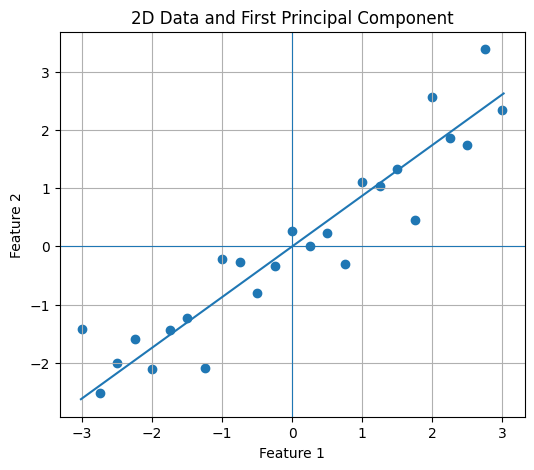

In [32]:
plt.figure(figsize=(6, 5))
plt.scatter(X_centered[:,0], X_centered[:,1])
line = np.linspace(-4, 4, 50)
plt.plot(line*pc1[0], line*pc1[1])
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("2D Data and First Principal Component")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

## 4. Linear Transformations

A matrix can transform vectors.

The slides use this matrix:

\[
A=
\begin{bmatrix}
3 & 1\\
1 & 2
\end{bmatrix}
\]

This matrix is non-singular because its determinant is non-zero.

In [33]:
A = np.array([
    [3, 1],
    [1, 2]
])

matrix_report("A", A)

A =
[[3. 1.]
 [1. 2.]]

Shape: (2, 2)
Determinant: 5.0
Singular? False
Non-singular? True
Inverse:
[[ 0.4 -0.2]
 [-0.2  0.6]]
Rank: 2


### Apply the Matrix to Basic Vectors

The standard basis vectors are:

\[
e_1 = (1,0), \quad e_2 = (0,1)
\]

A matrix transforms these into its columns.

In [34]:
e1 = np.array([1, 0])
e2 = np.array([0, 1])

print("A @ e1 =", A @ e1)
print("A @ e2 =", A @ e2)

print("\nThe columns of A are:")
print(A[:,0], A[:,1])

A @ e1 = [3 1]
A @ e2 = [1 2]

The columns of A are:
[3 1] [1 2]


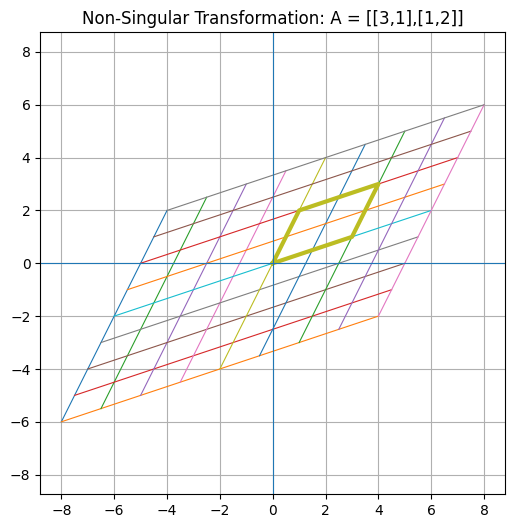

In [35]:
def plot_transformation(A, title="Linear Transformation"):
    A = np.array(A, dtype=float)
    grid = []
    for i in np.linspace(-2, 2, 9):
        grid.append(np.array([[i, -2], [i, 2]]))
        grid.append(np.array([[-2, i], [2, i]]))

    plt.figure(figsize=(6, 6))
    for segment in grid:
        transformed = segment @ A.T
        plt.plot(transformed[:,0], transformed[:,1], linewidth=0.8)

    unit_square = np.array([[0,0], [1,0], [1,1], [0,1], [0,0]])
    transformed_square = unit_square @ A.T
    plt.plot(transformed_square[:,0], transformed_square[:,1], linewidth=3)

    plt.axhline(0, linewidth=0.8)
    plt.axvline(0, linewidth=0.8)
    plt.title(title)
    plt.axis("equal")
    plt.grid(True)
    plt.show()

plot_transformation(A, "Non-Singular Transformation: A = [[3,1],[1,2]]")

## 5. Singular Transformations

A singular matrix collapses space into a lower dimension.

Example:

\[
B=
\begin{bmatrix}
1 & 1\\
2 & 2
\end{bmatrix}
\]

Its rows are multiples, so the determinant is zero.

B =
[[1. 1.]
 [2. 2.]]

Shape: (2, 2)
Determinant: 0.0
Singular? True
Non-singular? False
Rank: 1


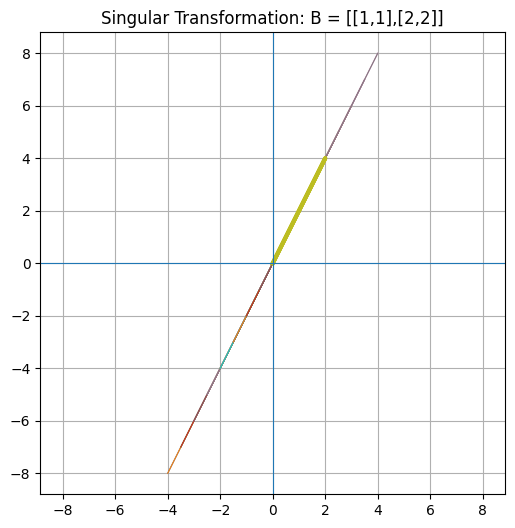

In [36]:
B = np.array([
    [1, 1],
    [2, 2]
])

matrix_report("B", B)
plot_transformation(B, "Singular Transformation: B = [[1,1],[2,2]]")

### Zero Matrix

The zero matrix collapses everything to the origin.

Z =
[[0. 0.]
 [0. 0.]]

Shape: (2, 2)
Determinant: 0.0
Singular? True
Non-singular? False
Rank: 0


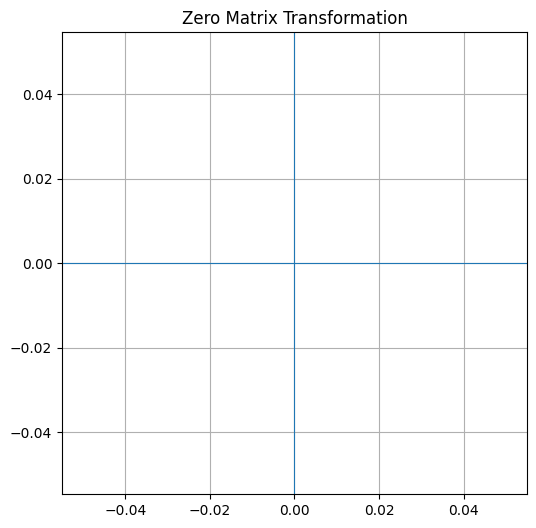

In [37]:
Z = np.array([
    [0, 0],
    [0, 0]
])

matrix_report("Z", Z)
plot_transformation(Z, "Zero Matrix Transformation")

## 6. Rank of a Linear Transformation

Rank describes the dimension of the output space.

From the slides:

- Non-singular matrix \(\rightarrow\) rank 2 in 2D
- Singular matrix that collapses to a line \(\rightarrow\) rank 1
- Zero matrix \(\rightarrow\) rank 0

In [38]:
matrices = {
    "A_non_singular": A,
    "B_singular_line": B,
    "Z_zero": Z
}

for name, M in matrices.items():
    print(name)
    print(M)
    print("Rank:", np.linalg.matrix_rank(M))
    print("Determinant:", np.linalg.det(M))
    print("-" * 40)

A_non_singular
[[3 1]
 [1 2]]
Rank: 2
Determinant: 5.000000000000001
----------------------------------------
B_singular_line
[[1 1]
 [2 2]]
Rank: 1
Determinant: 0.0
----------------------------------------
Z_zero
[[0 0]
 [0 0]]
Rank: 0
Determinant: 0.0
----------------------------------------


## 7. Determinant as Area

For a 2x2 matrix:

\[
\begin{bmatrix}
a & b\\
c & d
\end{bmatrix}
\]

the determinant is:

\[
ad-bc
\]

The absolute value of the determinant tells how much area is scaled.

In [39]:
A = np.array([
    [3, 1],
    [1, 2]
])

det_A = determinant_2x2(A)
print("det(A) =", det_A)
print("Area scale factor =", abs(det_A))

det(A) = 5.0
Area scale factor = 5.0


### Negative Determinants

A negative determinant means the transformation reverses orientation.

Example from the slides:

\[
C=
\begin{bmatrix}
1 & 3\\
2 & 1
\end{bmatrix}
\]

\[
\det(C)=1\cdot1-3\cdot2=-5
\]

C =
[[1. 3.]
 [2. 1.]]

Shape: (2, 2)
Determinant: -5.0
Singular? False
Non-singular? True
Inverse:
[[-0.2  0.6]
 [ 0.4 -0.2]]
Rank: 2


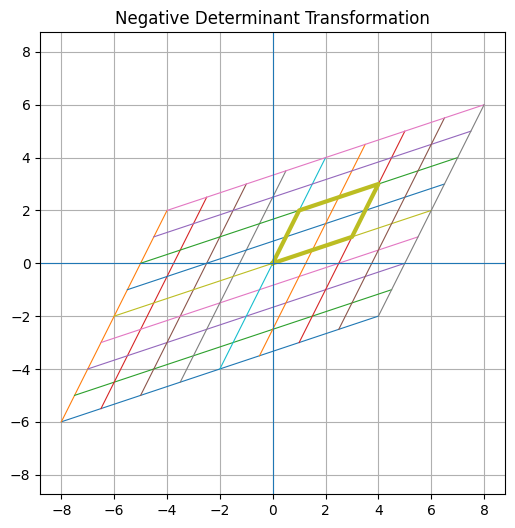

In [40]:
C = np.array([
    [1, 3],
    [2, 1]
])

matrix_report("C", C)
plot_transformation(C, "Negative Determinant Transformation")

## 8. Determinant of a Product

Important rule:

\[
\det(AB)=\det(A)\det(B)
\]

The slides show:

\[
\begin{bmatrix}
3&1\\
1&2
\end{bmatrix}
\begin{bmatrix}
5&2\\
1&2
\end{bmatrix}
=
\begin{bmatrix}
16&8\\
7&6
\end{bmatrix}
\]

with determinants \(5\), \(8\), and \(40\).

In [41]:
A = np.array([[3, 1], [1, 2]])
B2 = np.array([[5, 2], [1, 2]])
AB = A @ B2

print("A @ B2 =")
print(AB)

print("\ndet(A) =", np.linalg.det(A))
print("det(B2) =", np.linalg.det(B2))
print("det(A @ B2) =", np.linalg.det(AB))
print("det(A) * det(B2) =", np.linalg.det(A) * np.linalg.det(B2))

A @ B2 =
[[16  8]
 [ 7  6]]

det(A) = 5.000000000000001
det(B2) = 7.999999999999998
det(A @ B2) = 40.0
det(A) * det(B2) = 40.0


### Product With a Singular Matrix

If one factor is singular, the product is singular because:

\[
\det(AB)=\det(A)\det(B)
\]

If \(\det(B)=0\), then \(\det(AB)=0\).

In [42]:
A = np.array([[3, 1], [1, 2]])       # non-singular
S = np.array([[1, 2], [1, 2]])       # singular

AS = A @ S

print("A @ S =")
print(AS)

print("\ndet(A) =", np.linalg.det(A))
print("det(S) =", np.linalg.det(S))
print("det(A @ S) =", np.linalg.det(AS))

A @ S =
[[4 8]
 [3 6]]

det(A) = 5.000000000000001
det(S) = 0.0
det(A @ S) = 0.0


## 9. Determinant of an Inverse

Important rule:

\[
\det(A^{-1})=\frac{1}{\det(A)}
\]

This works only when \(A\) is invertible.

In [43]:
A = np.array([[3, 1], [1, 2]])
A_inv = np.linalg.inv(A)

print("A inverse:")
print(A_inv)

print("\ndet(A) =", np.linalg.det(A))
print("det(A inverse) =", np.linalg.det(A_inv))
print("1 / det(A) =", 1 / np.linalg.det(A))

A inverse:
[[ 0.4 -0.2]
 [-0.2  0.6]]

det(A) = 5.000000000000001
det(A inverse) = 0.19999999999999998
1 / det(A) = 0.19999999999999996


## 10. Bases and Span

A basis is a minimal spanning set.

In \(\mathbb{R}^2\), two independent vectors form a basis.

Example:

\[
v_1=(3,1), \quad v_2=(1,2)
\]

These form a basis because the matrix using them as columns has non-zero determinant.

In [44]:
basis = np.array([
    [3, 1],
    [1, 2]
])

matrix_report("Basis matrix", basis)

Basis matrix =
[[3. 1.]
 [1. 2.]]

Shape: (2, 2)
Determinant: 5.0
Singular? False
Non-singular? True
Inverse:
[[ 0.4 -0.2]
 [-0.2  0.6]]
Rank: 2


### Check Whether Vectors Form a Basis

In [45]:
def is_basis_2d(v1, v2):
    M = np.column_stack([v1, v2])
    det = np.linalg.det(M)
    return not np.isclose(det, 0), det

examples = [
    (np.array([3,1]), np.array([1,2])),
    (np.array([1,2]), np.array([2,4])),
    (np.array([1,0]), np.array([0,1]))
]

for v1, v2 in examples:
    result, det = is_basis_2d(v1, v2)
    print("v1 =", v1, "v2 =", v2)
    print("det =", det)
    print("Basis for R^2?", result)
    print("-" * 40)

v1 = [3 1] v2 = [1 2]
det = 5.000000000000001
Basis for R^2? True
----------------------------------------
v1 = [1 2] v2 = [2 4]
det = 0.0
Basis for R^2? False
----------------------------------------
v1 = [1 0] v2 = [0 1]
det = 1.0
Basis for R^2? True
----------------------------------------


## 11. Eigenvalues and Eigenvectors

An eigenvector is a vector whose direction does not change under a matrix transformation.

\[
Av = \lambda v
\]

where:

- \(v\) is the eigenvector
- \(\lambda\) is the eigenvalue

The slides use:

\[
A=
\begin{bmatrix}
2&1\\
0&3
\end{bmatrix}
\]

Its eigenvalues are 2 and 3.

In [46]:
A = np.array([
    [2, 1],
    [0, 3]
], dtype=float)

eigenvalues, eigenvectors = np.linalg.eig(A)

print("A =")
print(A)
print("\nEigenvalues:")
print(eigenvalues)
print("\nEigenvectors as columns:")
print(eigenvectors)

A =
[[2. 1.]
 [0. 3.]]

Eigenvalues:
[2. 3.]

Eigenvectors as columns:
[[1.     0.7071]
 [0.     0.7071]]


### Verify Eigenvector Equation

In [47]:
for i in range(len(eigenvalues)):
    lam = eigenvalues[i]
    v = eigenvectors[:, i]
    print(f"Eigenvalue λ = {lam}")
    print("v =", v)
    print("A @ v =", A @ v)
    print("λ * v =", lam * v)
    print("-" * 40)

Eigenvalue λ = 2.0
v = [1. 0.]
A @ v = [2. 0.]
λ * v = [2. 0.]
----------------------------------------
Eigenvalue λ = 3.0
v = [0.7071 0.7071]
A @ v = [2.1213 2.1213]
λ * v = [2.1213 2.1213]
----------------------------------------


### Manual Characteristic Polynomial

For

\[
A=
\begin{bmatrix}
2&1\\
0&3
\end{bmatrix}
\]

we solve:

\[
\det(A-\lambda I)=0
\]

\[
(2-\lambda)(3-\lambda)-1\cdot0=0
\]

So:

\[
\lambda=2,3
\]

In [48]:
if sympy_available:
    lam = sp.symbols('lambda')
    A_sp = sp.Matrix([[2, 1], [0, 3]])
    char_poly = (A_sp - lam * sp.eye(2)).det()
    print("Characteristic polynomial:")
    display(sp.factor(char_poly))
    print("Eigenvalues:")
    display(A_sp.eigenvals())
    print("Eigenvectors:")
    display(A_sp.eigenvects())
else:
    print("SymPy is not available. Install it with: %pip install sympy")

Characteristic polynomial:


(lambda - 3)*(lambda - 2)

Eigenvalues:


{3: 1, 2: 1}

Eigenvectors:


[(2,
  1,
  [Matrix([
   [1],
   [0]])]),
 (3,
  1,
  [Matrix([
   [1],
   [1]])])]

## 12. Eigenbasis

For the same matrix:

\[
A=
\begin{bmatrix}
2&1\\
0&3
\end{bmatrix}
\]

The eigenvectors can form a basis if they are linearly independent.

In the slides, eigenvectors include:

\[
(1,0), \quad (1,1)
\]

In [49]:
v1 = np.array([1, 0])
v2 = np.array([1, 1])

M = np.column_stack([v1, v2])

print("Eigenbasis matrix:")
print(M)
print("det =", np.linalg.det(M))
print("Do these vectors form a basis?", not np.isclose(np.linalg.det(M), 0))

print("\nCheck:")
print("A @ v1 =", A @ v1, "=", 2*v1)
print("A @ v2 =", A @ v2, "=", 3*v2)

Eigenbasis matrix:
[[1 1]
 [0 1]]
det = 1.0
Do these vectors form a basis? True

Check:
A @ v1 = [2. 0.] = [2 0]
A @ v2 = [3. 3.] = [3 3]


## 13. Quiz Example: Eigenvalues and Eigenvectors

From the slides:

\[
A=
\begin{bmatrix}
9&4\\
4&3
\end{bmatrix}
\]

Eigenvalues: \(11\) and \(1\)

Eigenvectors: \((2,1)\) and \((-1,2)\)

In [50]:
Q = np.array([
    [9, 4],
    [4, 3]
], dtype=float)

eigvals, eigvecs = np.linalg.eig(Q)

print("Q =")
print(Q)
print("\nEigenvalues:")
print(eigvals)
print("\nEigenvectors as columns:")
print(eigvecs)

print("\nVerification with slide eigenvectors:")
v1 = np.array([2, 1])
v2 = np.array([-1, 2])
print("Q @ (2,1) =", Q @ v1, "and 11*(2,1) =", 11*v1)
print("Q @ (-1,2) =", Q @ v2, "and 1*(-1,2) =", 1*v2)

Q =
[[9. 4.]
 [4. 3.]]

Eigenvalues:
[11.  1.]

Eigenvectors as columns:
[[ 0.8944 -0.4472]
 [ 0.4472  0.8944]]

Verification with slide eigenvectors:
Q @ (2,1) = [22. 11.] and 11*(2,1) = [22 11]
Q @ (-1,2) = [-1.  2.] and 1*(-1,2) = [-1  2]


## 14. Null Space

The null space of a matrix \(A\) is the set of all vectors \(x\) such that:

\[
Ax=0
\]

From the slides:

- Non-singular matrix has null space dimension 0.
- Singular line-collapsing matrix has null space dimension 1.
- Zero matrix in 2D has null space dimension 2.

In [51]:
def null_space_sympy(A):
    if not sympy_available:
        print("SymPy is not available. Install it with: %pip install sympy")
        return None
    A_sp = sp.Matrix(A)
    return A_sp.nullspace()

matrices = {
    "Non-singular": [[1,1],[1,2]],
    "Singular rank 1": [[1,1],[2,2]],
    "Zero matrix": [[0,0],[0,0]]
}

for name, M in matrices.items():
    print(name)
    print(np.array(M))
    print("Rank:", np.linalg.matrix_rank(np.array(M, dtype=float)))
    print("Nullity:", np.array(M).shape[1] - np.linalg.matrix_rank(np.array(M, dtype=float)))
    if sympy_available:
        print("Null space basis:", null_space_sympy(M))
    print("-" * 50)

Non-singular
[[1 1]
 [1 2]]
Rank: 2
Nullity: 0
Null space basis: []
--------------------------------------------------
Singular rank 1
[[1 1]
 [2 2]]
Rank: 1
Nullity: 1
Null space basis: [Matrix([
[-1],
[ 1]])]
--------------------------------------------------
Zero matrix
[[0 0]
 [0 0]]
Rank: 0
Nullity: 2
Null space basis: [Matrix([
[1],
[0]]), Matrix([
[0],
[1]])]
--------------------------------------------------


## 15. Null Space in 3D

Examples from the slides:

### Matrix 1

\[
\begin{bmatrix}
1&1&1\\
1&2&1\\
1&1&2
\end{bmatrix}
\]

Null space dimension: 0

### Matrix 2

\[
\begin{bmatrix}
1&1&1\\
1&1&2\\
1&1&3
\end{bmatrix}
\]

Null space dimension: 1

### Matrix 3

\[
\begin{bmatrix}
1&1&1\\
2&2&2\\
3&3&3
\end{bmatrix}
\]

Null space dimension: 2

### Matrix 4

Zero 3x3 matrix has null space dimension 3.

In [52]:
M1 = np.array([[1,1,1],[1,2,1],[1,1,2]])
M2 = np.array([[1,1,1],[1,1,2],[1,1,3]])
M3 = np.array([[1,1,1],[2,2,2],[3,3,3]])
M4 = np.zeros((3,3))

for name, M in [("M1", M1), ("M2", M2), ("M3", M3), ("M4", M4)]:
    print(name)
    print(M)
    rank = np.linalg.matrix_rank(M)
    nullity = M.shape[1] - rank
    print("Rank:", rank)
    print("Nullity / dimension of null space:", nullity)
    if sympy_available:
        print("Null space basis:", sp.Matrix(M).nullspace())
    print("-" * 50)

M1
[[1 1 1]
 [1 2 1]
 [1 1 2]]
Rank: 3
Nullity / dimension of null space: 0
Null space basis: []
--------------------------------------------------
M2
[[1 1 1]
 [1 1 2]
 [1 1 3]]
Rank: 2
Nullity / dimension of null space: 1
Null space basis: [Matrix([
[-1],
[ 1],
[ 0]])]
--------------------------------------------------
M3
[[1 1 1]
 [2 2 2]
 [3 3 3]]
Rank: 1
Nullity / dimension of null space: 2
Null space basis: [Matrix([
[-1],
[ 1],
[ 0]]), Matrix([
[-1],
[ 0],
[ 1]])]
--------------------------------------------------
M4
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
Rank: 0
Nullity / dimension of null space: 3
Null space basis: [Matrix([
[1],
[0],
[0]]), Matrix([
[0],
[1],
[0]]), Matrix([
[0],
[0],
[1]])]
--------------------------------------------------


## 16. Row Space

The row space is the span of the rows of a matrix.

Its dimension equals the rank.

Examples from the slides:

- Rank 2: row space is the whole plane.
- Rank 1: row space is a line.
- Rank 0: row space is just the zero point.

In [53]:
for name, M in [("A", [[3,1],[1,2]]), ("B", [[1,1],[2,2]]), ("Z", [[0,0],[0,0]])]:
    M_np = np.array(M, dtype=float)
    print(name)
    print(M_np)
    print("Rows:", M_np[0], M_np[1])
    print("Rank / dimension of row space:", np.linalg.matrix_rank(M_np))
    print("-" * 50)

A
[[3. 1.]
 [1. 2.]]
Rows: [3. 1.] [1. 2.]
Rank / dimension of row space: 2
--------------------------------------------------
B
[[1. 1.]
 [2. 2.]]
Rows: [1. 1.] [2. 2.]
Rank / dimension of row space: 1
--------------------------------------------------
Z
[[0. 0.]
 [0. 0.]]
Rows: [0. 0.] [0. 0.]
Rank / dimension of row space: 0
--------------------------------------------------


## 17. Orthogonal Matrices

Vectors are orthogonal if their dot product is zero.

The slides show columns:

\[
(6,2), \quad (-1,3)
\]

Dot product:

\[
6(-1)+2(3)=0
\]

So the columns are orthogonal.

In [54]:
u = np.array([6, 2])
v = np.array([-1, 3])

print("u dot v =", np.dot(u, v))
print("Are u and v orthogonal?", np.isclose(np.dot(u, v), 0))

u dot v = 0
Are u and v orthogonal? True


### Orthonormal Matrix

A matrix is orthonormal if its columns:

1. Are orthogonal
2. Each have norm 1

Example from the slides:

\[
Q=
\begin{bmatrix}
0.7071 & -0.7071\\
0.7071 & 0.7071
\end{bmatrix}
\]

For an orthonormal matrix:

\[
Q^TQ=I
\]

In [55]:
Q = np.array([
    [1/np.sqrt(2), -1/np.sqrt(2)],
    [1/np.sqrt(2),  1/np.sqrt(2)]
])

print("Q =")
print(Q)

print("\nQ.T @ Q =")
print(Q.T @ Q)

print("\nIs Q orthonormal?", np.allclose(Q.T @ Q, np.eye(2)))

Q =
[[ 0.7071 -0.7071]
 [ 0.7071  0.7071]]

Q.T @ Q =
[[1. 0.]
 [0. 1.]]

Is Q orthonormal? True


## 18. Linear Equations as Lines and Planes

A linear equation in 2 variables forms a line:

\[
a+b=10
\]

A linear equation in 3 variables forms a plane:

\[
a+b+c=1
\]

Below is a simple 3D plot of the plane \(a+b+c=1\).

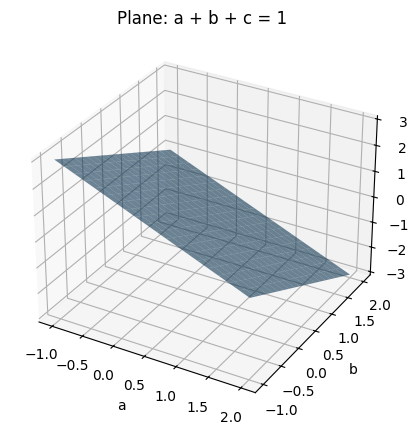

In [56]:
from mpl_toolkits.mplot3d import Axes3D

a = np.linspace(-1, 2, 20)
b = np.linspace(-1, 2, 20)
A_grid, B_grid = np.meshgrid(a, b)
C_grid = 1 - A_grid - B_grid

fig = plt.figure(figsize=(7, 5))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(A_grid, B_grid, C_grid, alpha=0.6)
ax.set_xlabel("a")
ax.set_ylabel("b")
ax.set_zlabel("c")
ax.set_title("Plane: a + b + c = 1")
plt.show()

## 19. Summary

Week 4 connects determinants, rank, bases, eigenvectors, and null spaces.

Key ideas:

- Determinant measures area/volume scaling.
- Non-zero determinant means non-singular and invertible.
- Zero determinant means singular.
- Rank measures dimension of the output/row/column space.
- Null space solves \(Ax=0\).
- Eigenvectors keep direction under a linear transformation.
- PCA uses eigenvectors to find important directions in data.